# ControlGen Mechanistic Visualization

This notebook visualizes the modular control-graph samples generated by ControlGen.

In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import numpy as np


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Could not locate repo root from notebook path")


ROOT = find_repo_root(Path.cwd().resolve())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

os.environ.setdefault("MPLCONFIGDIR", "/tmp/controlgen-mpl")

import matplotlib.pyplot as plt

from controlgen.generator import DatasetConfig, generate_sample

plt.style.use("seaborn-v0_8-whitegrid")
ROOT

PosixPath('/home/fan/AP/ControlGen')

In [2]:
def load_jsonl_sample(path: Path, index: int = 0) -> dict:
    with path.open("r", encoding="utf-8") as handle:
        for line_no, line in enumerate(handle):
            if line_no == index:
                return json.loads(line)
    raise IndexError(f"Sample index {index} out of range for {path}")


def summarize_sample(sample: dict) -> None:
    print("sample_id:", sample["sample_id"])
    print("graph_dsl:", sample["graph_dsl"])
    print("tags:", sample["tags"])
    print("scenario:", sample["scenario"])
    print("module_params:")
    for name, params in sample["module_params"].items():
        print(f"  {name}: {params}")
    print("metrics:")
    for family, values in sample["metrics"].items():
        print(f"  {family}: {values}")


def plot_sample(sample: dict) -> None:
    t = np.asarray(sample["t"], dtype=float)
    signals = {name: np.asarray(values, dtype=float) for name, values in sample["signals"].items()}

    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    axes[0].plot(t, signals["r"], linewidth=2, label="r")
    axes[0].plot(t, signals["d"], linewidth=2, label="d")
    axes[0].plot(t, signals["n"], linewidth=1.5, label="n")
    axes[0].set_title("External Signals")
    axes[0].legend(loc="upper right")

    axes[1].plot(t, signals["e"], linewidth=2, label="e")
    axes[1].plot(t, signals["u_cmd"], linewidth=2, label="u_cmd")
    axes[1].plot(t, signals["u_act"], linewidth=2, label="u_act")
    axes[1].set_title("Control Chain")
    axes[1].legend(loc="upper right")

    axes[2].plot(t, signals["y"], linewidth=2, label="y")
    axes[2].plot(t, signals["y_m"], linewidth=2, label="y_m")
    axes[2].plot(t, signals["r"], linewidth=1.5, linestyle="--", label="r")
    axes[2].set_title("Plant / Measurement Output")
    axes[2].set_xlabel("Time [s]")
    axes[2].legend(loc="upper right")

    fig.suptitle(sample["sample_id"])
    fig.tight_layout()
    plt.show()


## Generate a fresh sample

This cell draws a new mechanistic control-graph sample and visualizes the full signal chain.

sample_id: 457980c66d8c
graph_dsl: loop(reference=reference(kind='ramp', name='reference'), sum=sum(signs=[1, -1], name='error_sum'), controller=controller(kind='pid', name='controller'), actuator=actuator(kind='lag_saturation', name='actuator'), plant=plant(kind='second_order', name='plant'), disturbance=disturbance(kind='load_step', injection='output', name='disturbance'), sensor=sensor(kind='ideal', name='sensor'), noise=None, taps=[tap(signal='r', name='tap_r'), tap(signal='d', name='tap_d'), tap(signal='e', name='tap_e'), tap(signal='u_cmd', name='tap_u_cmd'), tap(signal='u_act', name='tap_u_act'), tap(signal='y', name='tap_y'), tap(signal='y_m', name='tap_y_m')])
tags: {'structure_family': 'saturated_actuator_loop', 'controller_family': 'pid', 'actuator_family': 'lag_saturation', 'plant_family': 'second_order', 'sensor_family': 'ideal', 'disturbance_family': 'load_step', 'noise_family': 'none', 'reference_family': 'ramp', 'realism_level': 'linear_with_disturbance_and_limits', 'cl

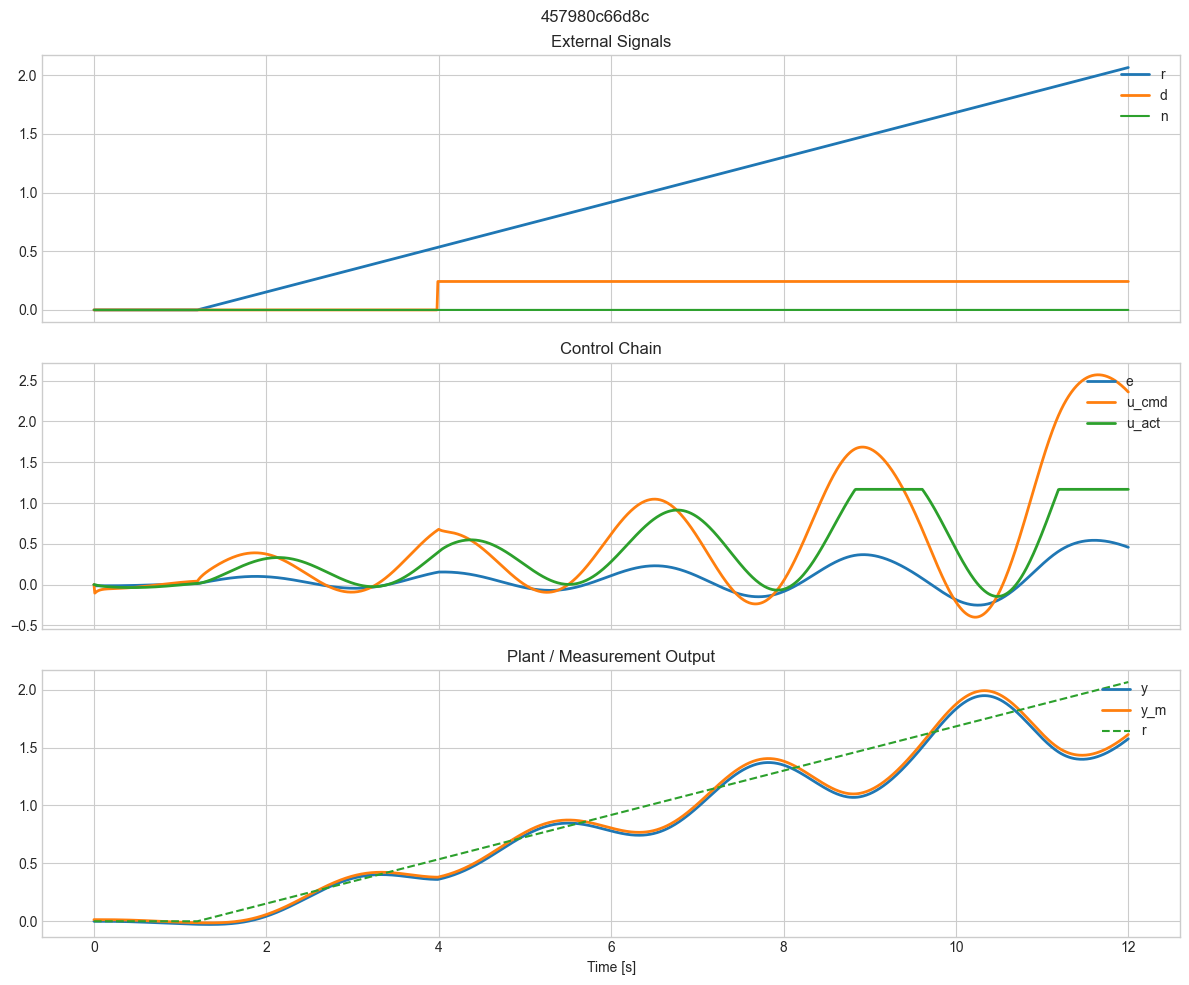

In [6]:
generated = generate_sample(DatasetConfig(seed=424232, count=1), sample_index=0).to_dict()
summarize_sample(generated)
plot_sample(generated)

## Load a sample from exported JSONL

After exporting data with `python3 -m controlgen.cli --count 100 --output artifacts/samples.jsonl`,
set `JSONL_PATH` and `SAMPLE_INDEX` below to inspect a saved row.

In [4]:
JSONL_PATH = ROOT / "artifacts" / "samples.jsonl"
SAMPLE_INDEX = 0

if JSONL_PATH.exists():
    loaded = load_jsonl_sample(JSONL_PATH, index=SAMPLE_INDEX)
    summarize_sample(loaded)
    plot_sample(loaded)
else:
    print(f"No JSONL file found at {JSONL_PATH}")

No JSONL file found at /home/fan/AP/ControlGen/artifacts/samples.jsonl
